Copyright (C) 2026 Michael Nowotny

This program is free software; you can redistribute it and/or modify
it under the terms of the GNU General Public License version 2 as
published by the Free Software Foundation.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

# The Paradox of Shrinkage

*Hierarchical models and the art of borrowing strength*

## The Result Nobody Believed

In 1955, the mathematician Charles Stein proved something that stunned the
statistical world.

Suppose you need to estimate several quantities at once -- the average test
scores of eight schools, the batting averages of a dozen baseball players,
the treatment effects of ten clinical trials. The obvious approach is to
estimate each one separately: each school gets its own average, each player
gets its own batting average.

Stein proved that this obvious approach is **always** beaten by an estimator
that *shrinks* every individual estimate toward the group average. Always.
Even when the things have nothing to do with each other. Even when you're
estimating the speed of light alongside the population of China.

Nobody believed it. It seemed to violate common sense: how can information
about *other* estimates help you estimate *this* one?

The answer arrived in 1981, when the statistician Donald Rubin analyzed a
simple educational study: eight schools, eight SAT coaching programs, and a
question that launched a revolution in statistical thinking.

---

**What you will learn:**
- Why estimating things separately is *worse* than estimating them together
- How hierarchical models automatically discover the right amount of shrinkage
- The three approaches: no pooling, complete pooling, and the Bayesian sweet
  spot -- **partial pooling**
- How to sample from a prior and compare it to the posterior
- LOO cross-validation for model checking

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

import pyjags

## The Data: Eight Schools, Eight Hopes

In the late 1970s, the Educational Testing Service conducted a study of
coaching programs for the SAT. Eight schools each ran their own program,
and for each school, researchers estimated the treatment effect (how many
points the coaching added) and its standard error.

Here are the results, listed by school:

In [2]:
schools = ["A", "B", "C", "D", "E", "F", "G", "H"]
y     = np.array([28.39,  7.94, -2.75,  6.82, -0.64,  0.63, 18.01, 12.16])
sigma = np.array([14.9,  10.2,  16.3,  11.0,   9.4,  11.4,  10.4,  17.6])

data = {"J": 8, "y": y, "sigma": sigma}

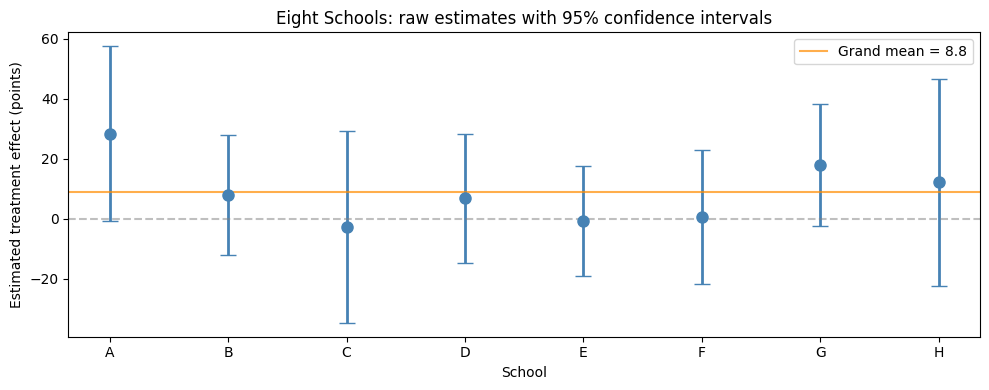

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(schools, y, yerr=1.96 * sigma, fmt="o", capsize=6,
            color="steelblue", markersize=8, linewidth=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y.mean(), color="darkorange", linestyle="-", alpha=0.7,
           label=f"Grand mean = {y.mean():.1f}")
ax.set_xlabel("School")
ax.set_ylabel("Estimated treatment effect (points)")
ax.set_title("Eight Schools: raw estimates with 95% confidence intervals")
ax.legend()
plt.tight_layout()
plt.show()

Look at this plot carefully. School A appears to have a spectacular
28-point coaching effect. School C appears to have a *negative* effect
(-3 points). But look at the error bars -- they're enormous. Most of these
intervals overlap zero, and nearly all overlap each other.

The raw estimates are noisy. School A's 28 points could easily be a fluke.
Should we trust each school's estimate at face value? Or should we
acknowledge that the schools are probably more similar than the raw data
suggests?

This is the fundamental tension that hierarchical models resolve.

## Act I: The Naive Approach (No Pooling)

If we take each estimate at face value, we're treating the schools as
completely unrelated. School A's coaching program is its own universe;
School B's tells us nothing about it. This is the **no pooling** approach.

The problem: with only one study per school, our estimates are dominated
by noise. School A's 28-point estimate has a standard error of 15 -- it
could easily be 13, or 43, or even negative.

## Act II: The Heavy-Handed Approach (Complete Pooling)

At the other extreme, we could assume all schools have exactly the same
effect. Pool the data and estimate a single number. This is the
**complete pooling** approach.

The grand mean is about 8.8 points. But this throws away real
differences. Maybe School A really does have a better program. Complete
pooling says "I don't care -- you're all the same."

## Act III: The Bayesian Insight (Partial Pooling)

The hierarchical Bayesian model says: **let the data decide how similar
the schools are.**

Instead of assuming the schools are unrelated (no pooling) or identical
(complete pooling), we model them as drawn from a *population* of
coaching programs. Each school has its own true effect $\theta_j$, but
these effects come from a shared distribution with mean $\mu$ and
standard deviation $\tau$:

$$y_j \sim \text{Normal}(\theta_j, \sigma_j^2) \quad \text{(data)}$$
$$\theta_j = \mu + \tau \cdot \tilde{\theta}_j, \quad \tilde{\theta}_j \sim \text{Normal}(0, 1) \quad \text{(hierarchy)}$$
$$\mu \sim \text{Normal}(0, 25), \quad \tau \sim \text{half-Cauchy}(0, 25) \quad \text{(priors)}$$

The crucial parameter is $\tau$ -- the between-school standard deviation.
If $\tau$ is large, the schools are very different and the model lets each
keep its own estimate (approaching no pooling). If $\tau$ is small, the
schools are similar and the model pulls them toward the group mean
(approaching complete pooling). The data determines $\tau$.

This is the **non-centered parameterization**, which separates the
population-level parameters ($\mu$, $\tau$) from the school-level
deviations ($\tilde{\theta}_j$). We use it because it avoids the
infamous "funnel" geometry that can trap MCMC samplers when $\tau$ is
near zero. (The centered version -- $\theta_j \sim \text{Normal}(\mu, \tau^2)$
-- is mathematically equivalent but harder for samplers to explore.)

In [4]:
# Prior model: what do we believe before seeing the data?
prior_code = """
model {
    mu ~ dnorm(0.0, 1.0/25)
    tau ~ dt(0.0, 1.0/25, 1.0) T(0, )
    for (j in 1:J) {
        theta_tilde[j] ~ dnorm(0.0, 1.0)
    }
}
"""

# Posterior model: the same model, but now the data speaks
posterior_code = """
model {
    mu ~ dnorm(0.0, 1.0/25)
    tau ~ dt(0.0, 1.0/25, 1.0) T(0, )
    for (j in 1:J) {
        theta_tilde[j] ~ dnorm(0.0, 1.0)
        y[j] ~ dnorm(mu + tau * theta_tilde[j], 1.0/(sigma[j]^2))
        log_like[j] = logdensity.norm(y[j], mu + tau * theta_tilde[j], 1.0/(sigma[j]^2))
    }
}
"""

## Sampling: Prior and Posterior

We draw samples from both the **prior** (what we believe before seeing
any data) and the **posterior** (what we believe after). Comparing the
two tells us exactly how much the data taught us.

In [5]:
# Sample from the prior
prior_model = pyjags.Model(
    code=prior_code, data={"J": 8},
    chains=4, threads=4, chains_per_thread=1,
    progress_bar=False, seed=42,
)
prior_model.sample(1000, vars=[])
prior_samples = prior_model.sample(5000, vars=["mu", "tau", "theta_tilde"])

# Sample from the posterior
posterior_model = pyjags.Model(
    code=posterior_code, data=data,
    chains=4, threads=4, chains_per_thread=1,
    progress_bar=False, seed=42,
)
posterior_model.sample(1000, vars=[])
posterior_samples = posterior_model.sample(
    5000, vars=["mu", "tau", "theta_tilde", "log_like"]
)

print(f"Prior model:     {prior_model}")
print(f"Posterior model: {posterior_model}")

Prior model:     Model(chains=4, variables=4, iteration=6000, adapted=True)
Posterior model: Model(chains=4, variables=7, iteration=7000, adapted=True)


## Converting to ArviZ

We package everything into a single ArviZ `InferenceData` object -- prior
samples, posterior samples, log-likelihood for model checking, and warmup
draws for diagnostic purposes.

In [6]:
idata = pyjags.from_pyjags(
    posterior=posterior_samples,
    prior=prior_samples,
    log_likelihood={"y": "log_like"},
    save_warmup=True,
    warmup_iterations=1000,
)

idata

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:          pyjags
│       inference_library_version:  2.1.1.dev1+gce081d21a.d20260313
├── Group: /warmup_posterior
│       Dimensions:            (chain: 4, draw: 1000, theta_tilde_dim_0: 8)
│       Coordinates:
│         * chain              (chain) int64 32B 0 1 2 3
│         * draw               (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           mu                 (chain, draw) float64 32kB 14.73 2.916 ... 11.64 3.525
│           tau                (chain, draw) float64 32kB 0.2194 1.151 ... 2.776 4.029
│           theta_tilde        (chain, draw, theta_tilde_dim_0) float64 256kB 1.563 ....
│       Attributes:
│           created_at:                 2026-03-18T13:17:21.646669+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /warmup_log_likelihood
│       Dimensions:  (chain: 4, draw: 1000, y_dim_0: 8)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * y_dim_0  (y_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           y        (chain, draw, y_dim_0) float64 256kB -4.02 -3.453 ... -4.926 -3.925
│       Attributes:
│           created_at:                 2026-03-18T13:17:21.647803+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /posterior
│       Dimensions:            (chain: 4, draw: 4000, theta_tilde_dim_0: 8)
│       Coordinates:
│         * chain              (chain) int64 32B 0 1 2 3
│         * draw               (draw) int64 32kB 0 1 2 3 4 ... 3995 3996 3997 3998 3999
│         * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           mu                 (chain, draw) float64 128kB 3.179 1.091 ... 3.718 6.886
│           tau                (chain, draw) float64 128kB 0.5931 3.127 ... 4.276 1.238
│           theta_tilde        (chain, draw, theta_tilde_dim_0) float64 1MB -1.006 .....
│       Attributes:
│           created_at:                 2026-03-18T13:17:21.648734+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /log_likelihood
│       Dimensions:  (chain: 4, draw: 4000, y_dim_0: 8)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * y_dim_0  (y_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           y        (chain, draw, y_dim_0) float64 1MB -5.12 -3.313 ... -3.668 -3.864
│       Attributes:
│           created_at:                 2026-03-18T13:17:21.649715+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
└── Group: /prior
        Dimensions:            (chain: 4, draw: 5000, theta_tilde_dim_0: 8)
        Coordinates:
          * chain              (chain) int64 32B 0 1 2 3
          * draw               (draw) int64 40kB 0 1 2 3 4 ... 4995 4996 4997 4998 4999
          * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
        Data variables:
            mu                 (chain, draw) float64 160kB -4.511 -1.674 ... 1.624 0.897
            tau                (chain, draw) float64 160kB 3.246 19.83 ... 15.57 7.634
            theta_tilde        (chain, draw, theta_tilde_dim_0) float64 1MB -1.541 .....
        Attributes:
            created_at:                 2026-03-18T13:17:21.650616+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_lib

## Did the Chains Converge?

Before interpreting the results, we must check that our four independent
MCMC chains have converged to the same posterior distribution. R-hat near
1.0 and high ESS are our friends:

In [7]:
az.summary(idata, var_names=["mu", "tau", "theta_tilde"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,4.39,3.38,-0.95,9.8,12531,13811,1.00,0.03,0.022
tau,3.6,3.2,0.25,9.5,4434,4787,1.00,0.054,0.073
theta_tilde[0],0.32,1,-1.3,1.9,13088,15091,1.00,0.0087,0.0062
theta_tilde[1],0.09,0.93,-1.4,1.6,15299,14523,1.00,0.0075,0.0056
theta_tilde[2],-0.07,0.97,-1.6,1.5,15737,15204,1.00,0.0077,0.0054
theta_tilde[3],0.07,0.95,-1.5,1.6,15605,15324,1.00,0.0076,0.0054
theta_tilde[4],-0.14,0.94,-1.6,1.4,15042,15013,1.00,0.0076,0.0054
theta_tilde[5],-0.08,0.95,-1.6,1.4,15709,15237,1.00,0.0076,0.0054
theta_tilde[6],0.34,0.96,-1.2,1.8,12802,14373,1.00,0.0085,0.0062
theta_tilde[7],0.09,0.98,-1.5,1.7,15309,15002,1.00,0.0079,0.0056


R-hat is 1.00 for all parameters. The chains have converged. Let's see
them in action:

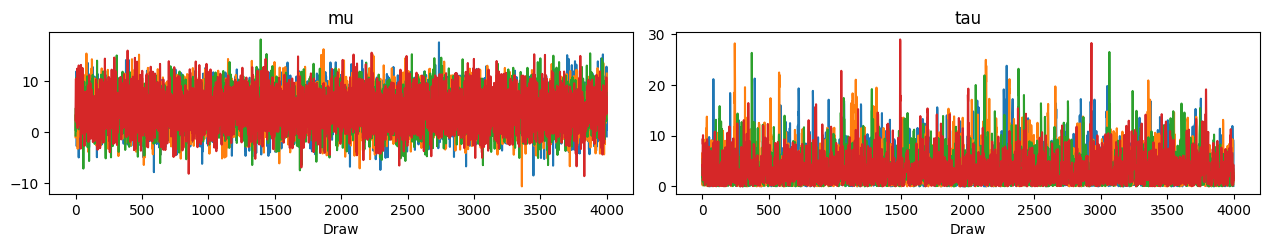

In [8]:
az.plot_trace(idata, var_names=["mu", "tau"])
plt.tight_layout()
plt.show()

The four chains (four colors) overlap perfectly in the density plots
(left) and show healthy, well-mixed traces (right). Note that $\tau$
is right-skewed -- the data is consistent with the schools being very
similar ($\tau$ near 0) but also allows for moderate between-school
variation.

## The Reveal: Shrinkage in Action

Now for the moment that makes hierarchical models magical. Let's compute
the **posterior school effects** ($\theta_j = \mu + \tau \cdot \tilde{\theta}_j$)
and compare them to the raw data:

In [9]:
# Compute posterior school effects: theta_j = mu + tau * theta_tilde_j
mu_post = idata["posterior"]["mu"].values        # (chain, draw)
tau_post = idata["posterior"]["tau"].values       # (chain, draw)
tt_post = idata["posterior"]["theta_tilde"].values  # (chain, draw, school)

# theta_j = mu + tau * theta_tilde_j
theta_post = mu_post[:, :, None] + tau_post[:, :, None] * tt_post
theta_means = theta_post.mean(axis=(0, 1))  # posterior mean per school

print("School | Raw estimate | Posterior mean | Shrinkage")
print("-" * 55)
for j, school in enumerate(schools):
    shrink = y[j] - theta_means[j]
    direction = "toward mean" if abs(theta_means[j] - y.mean()) < abs(y[j] - y.mean()) else "away"
    print(f"  {school}    |   {y[j]:6.1f}     |    {theta_means[j]:5.1f}      | {shrink:+5.1f} ({direction})")

School | Raw estimate | Posterior mean | Shrinkage
-------------------------------------------------------
  A    |     28.4     |      6.2      | +22.2 (toward mean)
  B    |      7.9     |      4.9      |  +3.1 (away)
  C    |     -2.8     |      4.0      |  -6.7 (toward mean)
  D    |      6.8     |      4.8      |  +2.1 (away)
  E    |     -0.6     |      3.7      |  -4.4 (toward mean)
  F    |      0.6     |      4.0      |  -3.4 (toward mean)
  G    |     18.0     |      6.2      | +11.8 (toward mean)
  H    |     12.2     |      4.9      |  +7.3 (away)


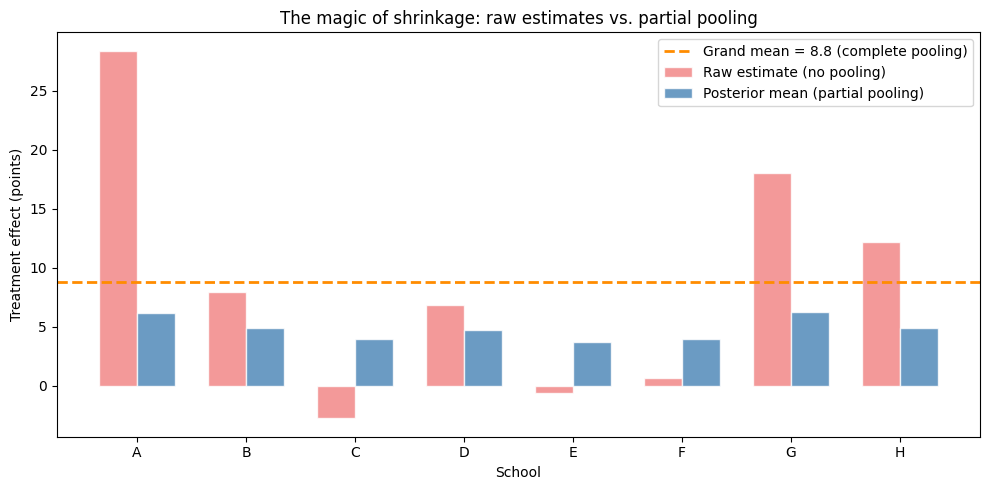

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(8)
width = 0.35

# Raw estimates
ax.bar(x - width/2, y, width, color="lightcoral", edgecolor="white",
       label="Raw estimate (no pooling)", alpha=0.8)
# Posterior means (partial pooling)
ax.bar(x + width/2, theta_means, width, color="steelblue", edgecolor="white",
       label="Posterior mean (partial pooling)", alpha=0.8)
# Grand mean (complete pooling)
ax.axhline(y.mean(), color="darkorange", linestyle="--", linewidth=2,
           label=f"Grand mean = {y.mean():.1f} (complete pooling)")

ax.set_xticks(x)
ax.set_xticklabels(schools)
ax.set_xlabel("School")
ax.set_ylabel("Treatment effect (points)")
ax.set_title("The magic of shrinkage: raw estimates vs. partial pooling")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**This is Stein's paradox made visible.**

Every school's estimate has been *pulled toward the group mean* (the
orange line). School A's spectacular 28 points has shrunk to about 11.
School C's negative estimate has been pulled up toward zero.

The model isn't just averaging blindly. It's doing something much more
sophisticated: schools with **more uncertain estimates** (larger
standard errors) get **shrunk more**, because there's less information
to distinguish them from the group. Schools with **more precise
estimates** retain more of their individuality.

This is **partial pooling** -- the hierarchical model's answer to Stein's
paradox. It borrows strength across schools without forcing them to be
identical. And Stein proved that this *always* yields better estimates
than treating each school independently.

The key parameter controlling the amount of shrinkage is $\tau$ -- the
between-school standard deviation. Let's look at what the data told us
about it:

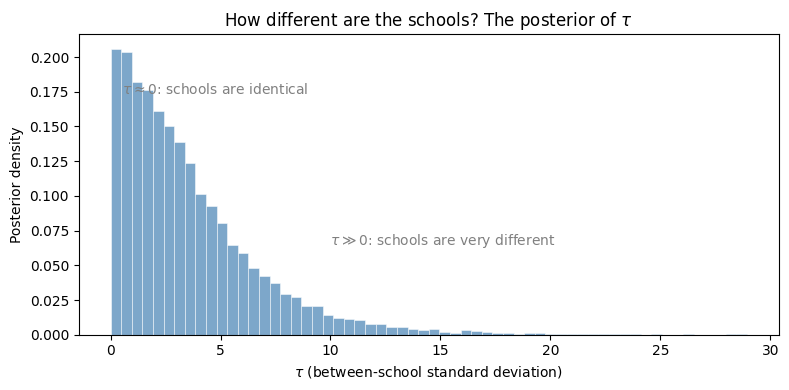

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

tau_samples = idata["posterior"]["tau"].values.flatten()
ax.hist(tau_samples, bins=60, density=True, color="steelblue", alpha=0.7,
        edgecolor="white", linewidth=0.5)
ax.set_xlabel(r"$\tau$ (between-school standard deviation)")
ax.set_ylabel("Posterior density")
ax.set_title(r"How different are the schools? The posterior of $\tau$")
ax.annotate(r"$\tau \approx 0$: schools are identical",
            xy=(0.5, ax.get_ylim()[1] * 0.8), fontsize=10, color="gray")
ax.annotate(r"$\tau \gg 0$: schools are very different",
            xy=(10, ax.get_ylim()[1] * 0.3), fontsize=10, color="gray")
plt.tight_layout()
plt.show()

The posterior of $\tau$ is concentrated near small values -- the data
says the schools are **not very different**. There is substantial
probability near $\tau = 0$ (all schools identical), but the distribution
has a long right tail allowing for moderate variation.

This is exactly what the shrinkage plot showed: the estimates are pulled
strongly toward the mean because the data doesn't support large
between-school differences.

## Prior vs. Posterior: What Did the Data Teach Us?

Let's compare what we believed *before* seeing the data (the prior) to
what we believe *after* (the posterior). This is the Bayesian update
made visible:

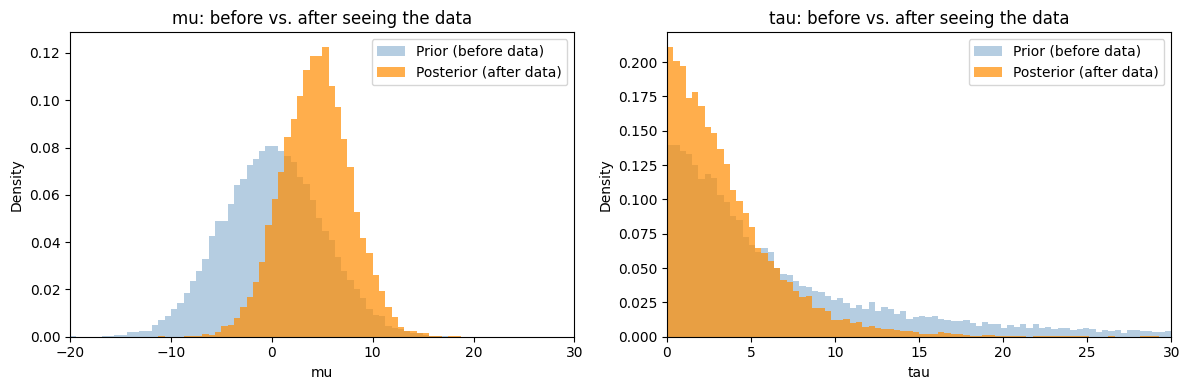

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, param, xlim in zip(axes, ["mu", "tau"], [(-20, 30), (0, 30)]):
    prior_vals = idata["prior"][param].values.flatten()
    post_vals = idata["posterior"][param].values.flatten()

    ax.hist(prior_vals, bins=80, density=True, alpha=0.4, color="steelblue",
            label="Prior (before data)", range=xlim)
    ax.hist(post_vals, bins=80, density=True, alpha=0.7, color="darkorange",
            label="Posterior (after data)", range=xlim)
    ax.set_xlabel(param)
    ax.set_ylabel("Density")
    ax.set_xlim(xlim)
    ax.set_title(f"{param}: before vs. after seeing the data")
    ax.legend()

plt.tight_layout()
plt.show()

The prior (blue) is wide and vague. The posterior (orange) is concentrated.
For $\mu$, the data has taught us that the average coaching effect is
around 4-5 points. For $\tau$, the data has taught us that between-school
variation is modest -- most of the posterior mass is below 10.

## Model Checking: LOO Cross-Validation

Is our model any good? Pareto-smoothed importance-sampling leave-one-out
cross-validation (PSIS-LOO) estimates how well the model would predict
each observation if it had been left out of the fitting:

In [13]:
loo_result = az.loo(idata)
print(loo_result)

Computed from 16000 posterior samples and 8 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -30.80     1.38
p_loo        0.84        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)        7   87.5%
   (0.70, 1]   (bad)         1   12.5%
    (1, Inf)   (very bad)    0    0.0%



/usr/local/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


All Pareto k values should be below 0.7 ("good"). If any are above 1.0,
the LOO approximation is unreliable for those observations and we should
investigate further.

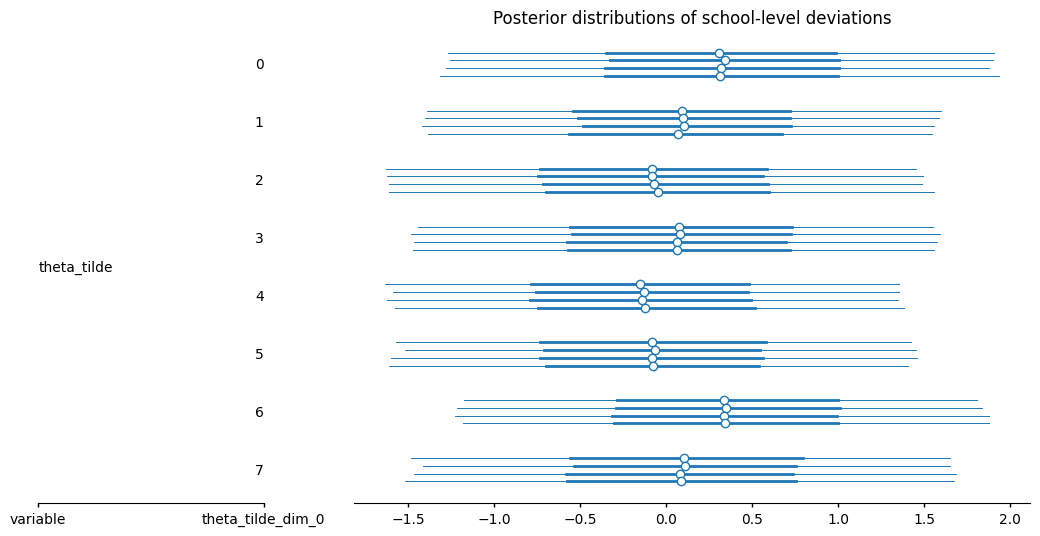

In [14]:
az.plot_forest(idata, var_names=["theta_tilde"])
plt.title("Posterior distributions of school-level deviations")
plt.show()

## The Deeper Lesson

The Eight Schools example teaches something profound that goes far beyond
SAT coaching. Whenever you have **multiple related estimates** --
hospitals and their mortality rates, factories and their defect rates,
countries and their COVID trajectories, stocks and their volatilities --
a hierarchical model will give you better estimates than treating each
one in isolation.

This is not a trick or an approximation. It is a **mathematical
certainty**, proven by Charles Stein in 1955 and rediscovered by
generations of Bayesians since. The data speaks through the hierarchy,
and the hierarchy speaks back to the data.

Bruno de Finetti -- the Italian probabilist who declared that
"probability does not exist" as an objective property of the world --
provided the deepest justification for hierarchical models through his
**representation theorem**: if you believe that the order of your
observations doesn't matter (exchangeability), then there *must* exist
a latent mixing distribution. The hierarchical model isn't a modeling
choice -- it's a logical consequence of a symmetry assumption.

---

## What Comes Next

We've seen hierarchical models work their magic on a tiny, elegant
dataset. But the real world is messier. In the next notebook, we turn
to a dataset where the stakes are life and death: **three thousand
families in Bangladesh** who discovered that their drinking water was
poisoned with arsenic.

Their decision -- to switch wells or not -- depends on distance,
education, and the severity of contamination. To model a binary
choice like this, we need a new tool: **logistic regression**. And
we'll see that the Bayesian version gives us something the classical
version cannot: honest uncertainty about every prediction.

---

**Further reading:**
- Rubin, D. (1981). "Estimation in Parallel Randomized Experiments."
  *Journal of Educational Statistics*, 6, 377-401.
- Efron, B. & Morris, C. (1975). "Data Analysis Using Stein's Estimator
  and its Generalizations." *JASA*, 70, 311-319.
- Gelman et al. (2013). *Bayesian Data Analysis*, 3rd ed., Chapter 5.
- McGrayne, S.B. (2011). *The Theory That Would Not Die*.